In [16]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

First read in the preprocessed data

In [2]:
df = pd.read_csv("data/ConcreteData_cleaned.csv")
y = df['Concrete compressive strength']
X_test_norm = pd.read_csv("data/X_test_normalized.csv",index_col='Unnamed: 0')
X_train_norm = pd.read_csv("data/X_train_normalized.csv",index_col='Unnamed: 0')
y_train = y[X_train_norm.index]
y_test = y[X_test_norm.index]

Define a function to add the features originally explored in the EDA step

In [3]:
def add_engineered_features(df):
    #For ingredients that are commonly 0, create feature that is 1 if the mixture contains any and 0 if not
    df['contains_BlastFurnaceSlag'] = (df['Blast Furnace Slag'] != 0)*1
    df['contains_FlyAsh'] = (df['Fly Ash'] != 0)*1
    df['contains_Superplasticizer'] = (df['Superplasticizer'] != 0)*1

    #Some ratios
    df['w_c_ratio'] = df['Water']/df['Cement']
    df['w_binder_ratio'] = df['Water']/(df['Cement']+df['Fly Ash']+df['Blast Furnace Slag'])
    df['sp_binder_ratio'] = df['Superplasticizer']/(df['Cement']+df['Fly Ash']+df['Blast Furnace Slag'])
    df['fa_binder_ratio'] = df['Fly Ash']/(df['Cement']+df['Fly Ash']+df['Blast Furnace Slag'])
    df['bfs_binder_ratio'] = df['Blast Furnace Slag']/(df['Cement']+df['Fly Ash']+df['Blast Furnace Slag'])
    df['bfs_fa_binder_ratio'] = (df['Blast Furnace Slag']+df['Fly Ash'])/(df['Cement']+df['Fly Ash']+df['Blast Furnace Slag'])

    return df

In [4]:
X_train_norm = add_engineered_features(X_train_norm)
X_test_norm = add_engineered_features(X_test_norm)

# Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import cross_validate

LRmodel = LinearRegression()

scoring = ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']
cv_results = cross_validate(LRmodel,X_train_norm,y_train,cv=5,scoring=scoring)

In [12]:
print(f"training set r2 = {cv_results['test_r2'].mean()}")
print(f"training set MAE = {-cv_results['test_neg_mean_absolute_error'].mean()}")
print(f"training set RMSE = {-cv_results['test_neg_root_mean_squared_error'].mean()}")

training set r2 = 0.6305653684300817
training set MAE = 7.813417852199183
training set RMSE = 9.929524662592758


In [8]:
LRmodel.fit(X_train_norm,y_train)
pred = LRmodel.predict(X_test_norm)
r2_test = r2_score(y_test,pred)
mae_test = mean_absolute_error(y_test,pred)
rmse_test = root_mean_squared_error(y_test,pred)

In [10]:
print(f"test set r2 = {r2_test}")
print(f"test set MAE = {mae_test}")
print(f"test set RMSE = {rmse_test}")

test set r2 = 0.6563160150765746
test set MAE = 7.42354875532824
test set RMSE = 9.254131905918571


Try with the min-max scaled version of the data....

In [19]:
X_test_scaled = pd.read_csv("data/X_test_scaled.csv",index_col='Unnamed: 0')
X_train_scaled = pd.read_csv("data/X_train_scaled.csv",index_col='Unnamed: 0')

X_test_scaled = add_engineered_features(X_test_scaled)
X_train_scaled = add_engineered_features(X_train_scaled)

In [20]:
cv_results = cross_validate(LRmodel,X_train_scaled,y_train,cv=5,scoring=scoring)

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\linear_model\_base.py", line 618, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\utils\validation.py", line 2971, in validate_data
    X, y = check_X_y(X, y, **check_params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\utils\validation.py", line 1368, in check_X_y
    X = check_array(
        ^^^^^^^^^^^^
  File "c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\utils\validation.py", line 1105, in check_array
    _assert_all_finite(
  File "c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\utils\validation.py", line 120, in _assert_all_finite
    _assert_all_finite_element_wise(
  File "c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\utils\validation.py", line 169, in _assert_all_finite_element_wise
    raise ValueError(msg_err)
ValueError: Input X contains infinity or a value too large for dtype('float64').


We get errors because some rows have infinite values from divide-by-zero errors. Let's just stick with the normalized data set for now...

In [24]:
X_train_scaled[X_train_scaled['Cement']==0]

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,contains_BlastFurnaceSlag,contains_FlyAsh,contains_Superplasticizer,w_c_ratio,w_binder_ratio,sp_binder_ratio,fa_binder_ratio,bfs_binder_ratio,bfs_fa_binder_ratio
635,0.0,0.42571,0.0,0.560878,0.0,0.25,0.873056,0.011050,1,0,0,inf,1.317514,0.0,0.0,1.0,1.0
638,0.0,0.42571,0.0,0.560878,0.0,0.25,0.873056,0.069061,1,0,0,inf,1.317514,0.0,0.0,1.0,1.0


# Random Forest Model

To limit total number of fits, we will do an initital grid search for one hyper-parameter, n_estimators

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

RFmodel = RandomForestRegressor()

param_grid = {'n_estimators': np.arange(50,550,50)}

grid_search = GridSearchCV(RFmodel, cv=5, scoring='neg_mean_absolute_error', verbose=1, param_grid=param_grid)

grid_search.fit(X_train_norm,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,RandomForestRegressor()
,param_grid,"{'n_estimators': array([ 50, 1...00, 450, 500])}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


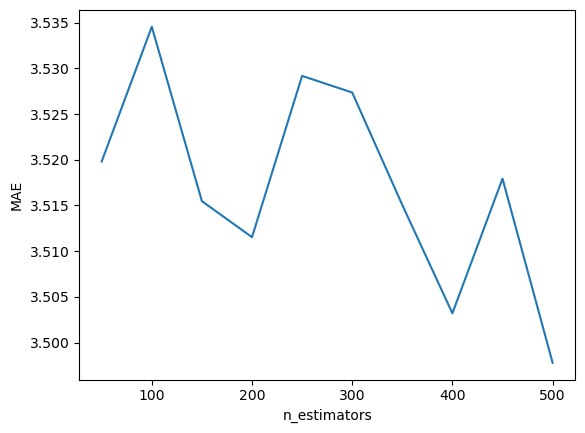

In [51]:
plt.plot(np.arange(50,550,50),-grid_search.cv_results_['mean_test_score'])
plt.xlabel("n_estimators")
plt.ylabel("MAE")
plt.show()

As expected, the more trees the better but the improvement isn't that strong

Now another grid search for the other hyper-parameters

In [55]:
param_grid = {'n_estimators': [500],
              'max_depth': [None, 5, 10],
              'min_samples_split': [2, 0.01, 0.05, 0.1],
              'min_samples_leaf': [1, 2, 5, 10, 100]}

grid_search = GridSearchCV(RFmodel, cv=5, scoring='neg_mean_absolute_error', verbose=1, param_grid=param_grid)

grid_search.fit(X_train_norm,y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 0.01, ...], 'n_estimators': [500]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [56]:
grid_search.best_params_

{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 500}

These are the defaults for the rest of the hyper-parameters

In [57]:
RFmodel = RandomForestRegressor(n_estimators=500)
cv_results = cross_validate(RFmodel,X_train_norm,y_train,cv=5,scoring=scoring)

In [58]:
print(f"training set r2 = {cv_results['test_r2'].mean()}")
print(f"training set MAE = {-cv_results['test_neg_mean_absolute_error'].mean()}")
print(f"training set RMSE = {-cv_results['test_neg_root_mean_squared_error'].mean()}")

training set r2 = 0.9010573138685422
training set MAE = 3.519587350516312
training set RMSE = 5.123705855920132


In [59]:
RFmodel.fit(X_train_norm,y_train)
pred = RFmodel.predict(X_test_norm)
r2_test = r2_score(y_test,pred)
mae_test = mean_absolute_error(y_test,pred)
rmse_test = root_mean_squared_error(y_test,pred)

In [60]:
print(f"test set r2 = {r2_test}")
print(f"test set MAE = {mae_test}")
print(f"test set RMSE = {rmse_test}")

test set r2 = 0.9184024986724757
test set MAE = 3.336588021757474
test set RMSE = 4.509147770457544


The results are much better for the random forest model. The error in the test predictions is actually slightly lower than that of the training set.

# Gradient Boosting Model

In [63]:
from sklearn.ensemble import GradientBoostingRegressor

GBmodel = GradientBoostingRegressor()

param_grid = {'n_estimators': np.arange(50,550,50),
              'learning_rate': [0.1, 0.2, 0.5, 0.7, 1.0]}

grid_search = GridSearchCV(GBmodel, cv=5, scoring='neg_mean_absolute_error', verbose=1, param_grid=param_grid)

grid_search.fit(X_train_norm,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,GradientBoostingRegressor()
,param_grid,"{'learning_rate': [0.1, 0.2, ...], 'n_estimators': array([ 50, 1...00, 450, 500])}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [64]:
grid_search.best_params_

{'learning_rate': 0.2, 'n_estimators': 500}

In [65]:
GBmodel = GradientBoostingRegressor(n_estimators=500, learning_rate=0.2)
cv_results = cross_validate(GBmodel,X_train_norm,y_train,cv=5,scoring=scoring)

In [66]:
print(f"training set r2 = {cv_results['test_r2'].mean()}")
print(f"training set MAE = {-cv_results['test_neg_mean_absolute_error'].mean()}")
print(f"training set RMSE = {-cv_results['test_neg_root_mean_squared_error'].mean()}")

training set r2 = 0.924221700070931
training set MAE = 2.8822702060923318
training set RMSE = 4.474784701818661


In [67]:
GBmodel.fit(X_train_norm,y_train)
pred = GBmodel.predict(X_test_norm)
r2_test = r2_score(y_test,pred)
mae_test = mean_absolute_error(y_test,pred)
rmse_test = root_mean_squared_error(y_test,pred)

In [68]:
print(f"test set r2 = {r2_test}")
print(f"test set MAE = {mae_test}")
print(f"test set RMSE = {rmse_test}")

test set r2 = 0.9273943867543997
test set MAE = 2.7897652820357077
test set RMSE = 4.2534480892528626


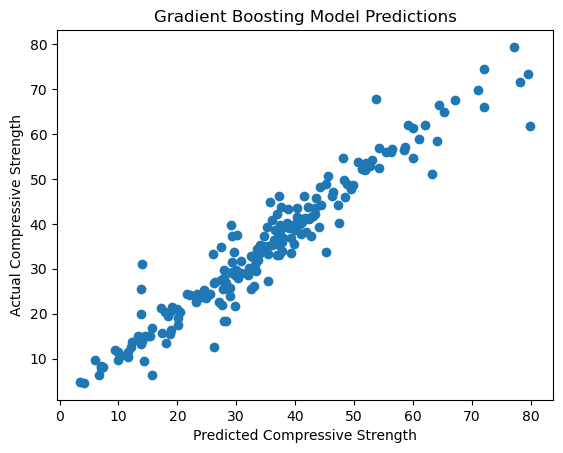

In [72]:
plt.scatter(pred,y_test)
plt.xlabel("Predicted Compressive Strength")
plt.ylabel("Actual Compressive Strength")
plt.title("Gradient Boosting Model Predictions")
plt.show()

The gradient boosting model edges out the random forest model in terms of all three of the metrics investigated here. We will consider this the winning model!